**CHIAMAKA EGBUKOLE**

**G40486569**

###Individual Homework 2
Reproducing the Lecture 1 & 2 COMPAS Workflow in Python

In [36]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##1. Data Loading and Cleaning

In [37]:
#Load the raw COMPAS data
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(raw_data.shape)
raw_data.head()

(7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [38]:
#I kept the variables used in class slides
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

In [39]:
# Then I apply the same filtering rules from Lecture 1
df = df[
    (df["days_b_screening_arrest"] >= -30) &
    (df["days_b_screening_arrest"] <= 30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

print(df.shape)

(6172, 13)


In [40]:
#Type conversions and derived variables
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], errors="coerce")

In [41]:
#I created the modeling variables:
df["crime_factor"] = df["c_charge_degree"]
df["age_factor"] = pd.Categorical(df["age_cat"], categories=["25 - 45", "Greater than 45", "Less than 25"])
df['race_factor'] = pd.Categorical(df['race'], categories=['Caucasian', 'African-American', 'Hispanic', 'Other', 'Asian', 'Native American'])
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])
df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = pd.Categorical(df["score_factor"], categories=["LowScore", "HighScore"])

In [42]:
#Basic EDA

print(df.info())
print(df.describe())

print(df["race"].value_counts())
print(df["score_text"].value_counts())
print(df["two_year_recid"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

## Data Cleaning and Exploration

After applying the same filtering steps from Lecture 1, the dataset contains around 6,172 observations, which matches what we saw in class. This suggests that the preprocessing was done correctly.

From the summary statistics and plots, most defendants are classified as "Low" risk, with fewer in the "Medium" and "High" categories. The distribution of prior arrests is highly skewed to the right, meaning most individuals have few prior arrests, but a small number have many.

The race distribution also shows that African-American and Caucasian defendants make up the majority of the dataset, which is important to keep in mind when interpreting fairness results later.

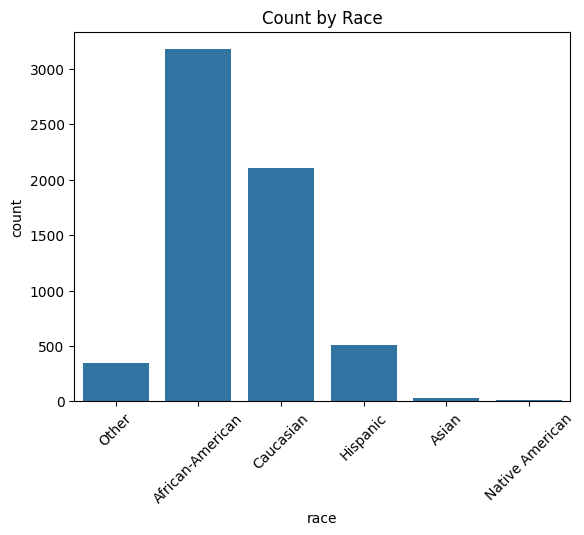

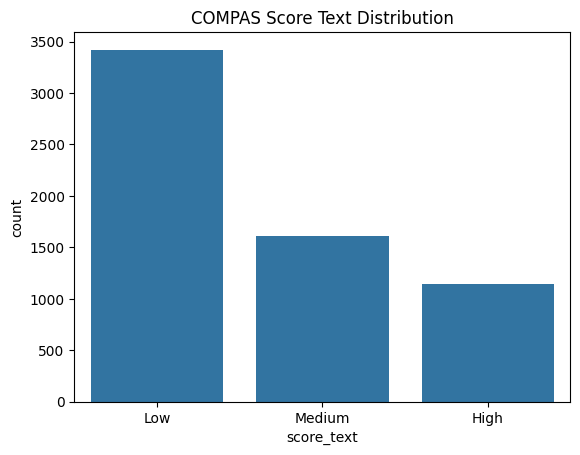

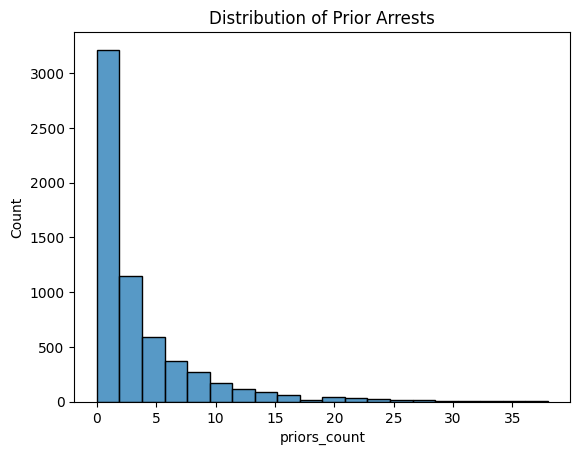

In [43]:
#Basic EDA visualizations

sns.countplot(data=df, x="race")
plt.title("Count by Race")
plt.xticks(rotation=45)
plt.show()

sns.countplot(data=df, x="score_text")
plt.title("COMPAS Score Text Distribution")
plt.show()

sns.histplot(df["priors_count"], bins=20)
plt.title("Distribution of Prior Arrests")
plt.show()

## **INDIVIDUAL ASSIGNMENT 2**

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


## 2. Train/Test Split and Model Setup

For this assignment, I use a train/test split and a sklearn pipeline so that the model can be used with SHAP, LIME, and DiCE. I fit a logistic regression model, which is the interpretable-by-design model discussed in Lecture 2.

In [45]:
#Train/Test Split
features = ["priors_count", "age_factor", "race_factor", "gender_factor", "crime_factor"]

X = df[features]
y = df["two_year_recid"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4937, 5)
Test shape: (1235, 5)


In [46]:
#The Model
numeric_features = ["priors_count"]
categorical_features = ["age_factor", "race_factor", "gender_factor", "crime_factor"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_factor', 'race_factor',
                                                   'gender_factor',
                                                   'crime_factor'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

## 3. Select the Four Individuals for Explanation

The assignment asks for explanations for the highest-risk and lowest-risk defendants in each racial group. To keep the analysis focused and consistent with the Lecture 2 framing, I use four individuals total: the lowest-risk and highest-risk African-American defendants, and the lowest-risk and highest-risk Caucasian defendants.

In [47]:
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = model.predict_proba(X_test)[:,1]

# highest + lowest for each race
groups = X_test_copy.groupby("race_factor")

selected_indices = []

for race, g in groups:
    selected_indices.append(g.sort_values("pred_prob").index[0])   # lowest
    selected_indices.append(g.sort_values("pred_prob").index[-1])  # highest

/tmp/ipykernel_2688/1878335207.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = X_test_copy.groupby("race_factor")


#**OR**

In [49]:
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = model.predict_proba(X_test)[:, 1]

black_group = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
white_group = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")

selected_cases = {
    "Lowest-risk African-American": black_group.index[0],
    "Highest-risk African-American": black_group.index[-1],
    "Lowest-risk Caucasian": white_group.index[0],
    "Highest-risk Caucasian": white_group.index[-1],
}

selected_cases

{'Lowest-risk African-American': np.int64(3073),
 'Highest-risk African-American': np.int64(6825),
 'Lowest-risk Caucasian': np.int64(638),
 'Highest-risk Caucasian': np.int64(6417)}

## 4. SHAP Analysis

I first use SHAP to explain the model. The beeswarm plot gives a global view of which features matter most overall, while the waterfall plots show how encoded features push each individual prediction up or down relative to the baseline.

In [50]:
#SHAP
!pip install shap

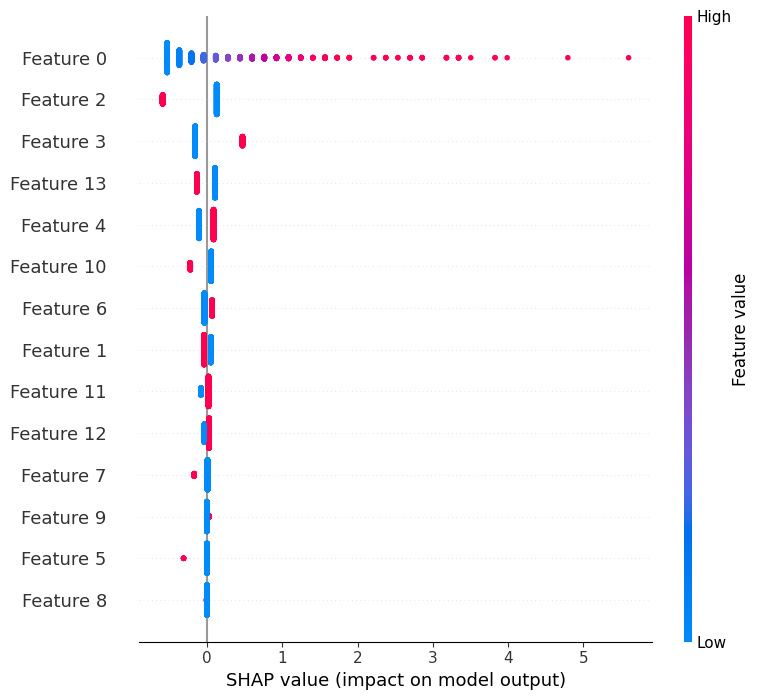

In [51]:
import shap

X_test_enc = preprocessor.transform(X_test)
X_test_enc = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

explainer = shap.Explainer(model["classifier"], X_test_enc)
shap_values = explainer(X_test_enc)

shap.summary_plot(shap_values, X_test_enc)

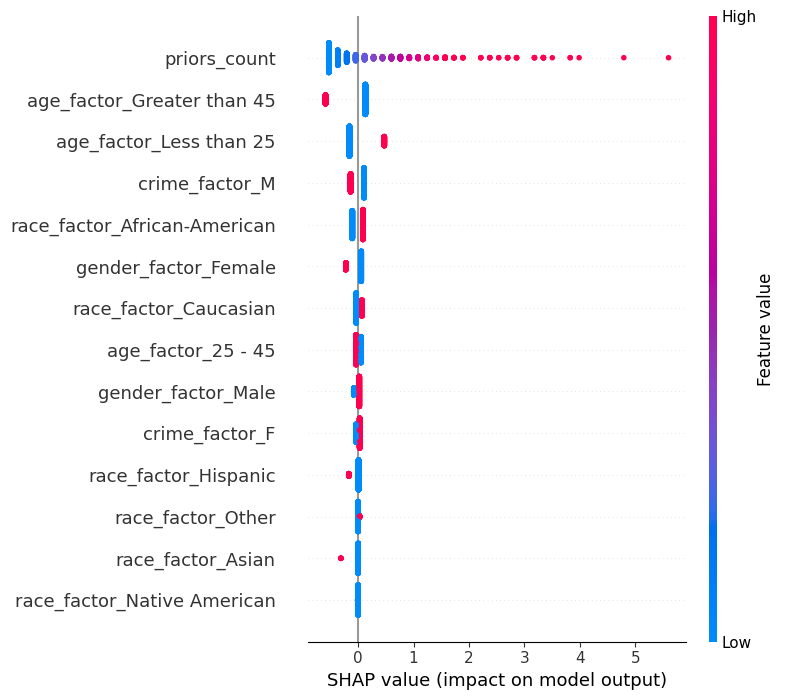

In [52]:
#Beeswarm (Global)
feature_names = numeric_features + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)

shap.summary_plot(
    shap_values.values,
    X_test_enc,
    feature_names=feature_names
)

### SHAP Beeswarm Interpretation

The beeswarm plot gives a global explanation of the model by showing which encoded features have the largest overall effect on predictions. Features that appear more spread out across the x-axis have a stronger impact on predicted recidivism risk. This helps identify which parts of the model matter most overall, even before looking at individual defendants.

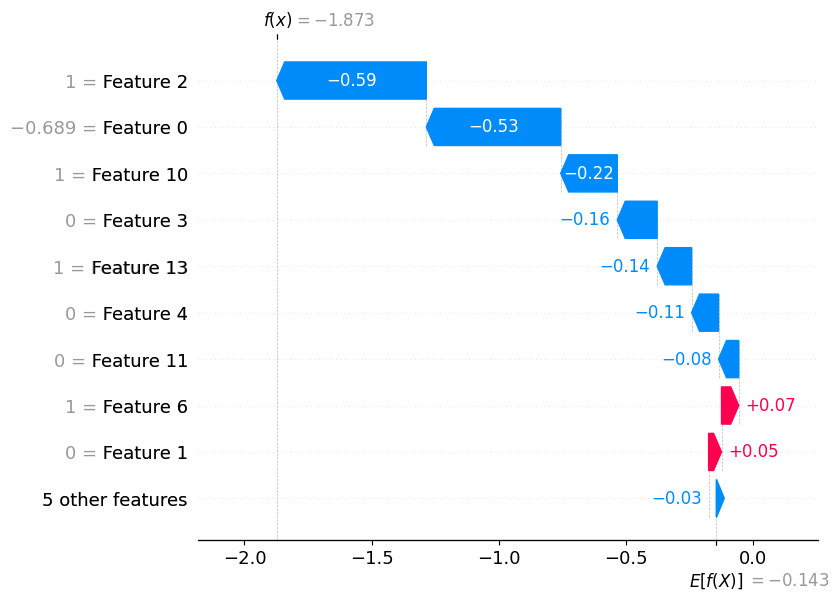

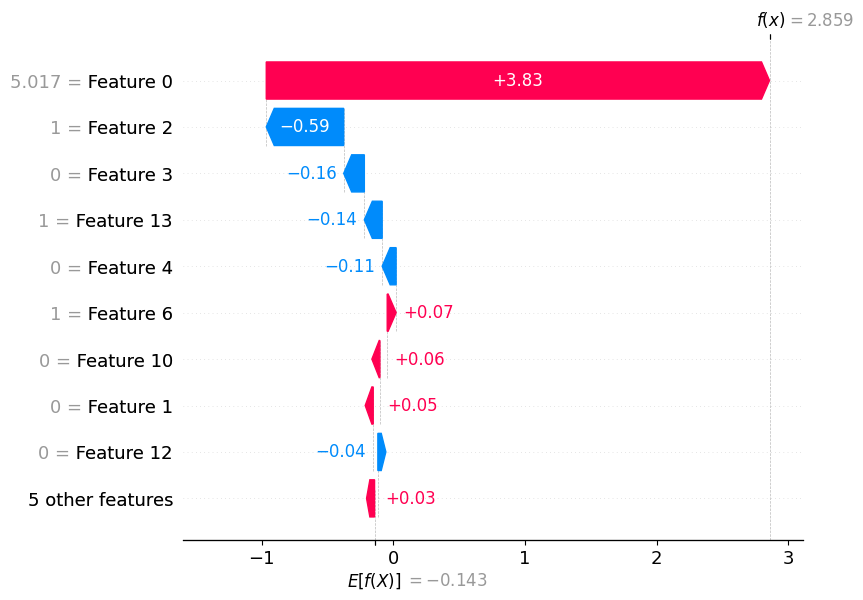

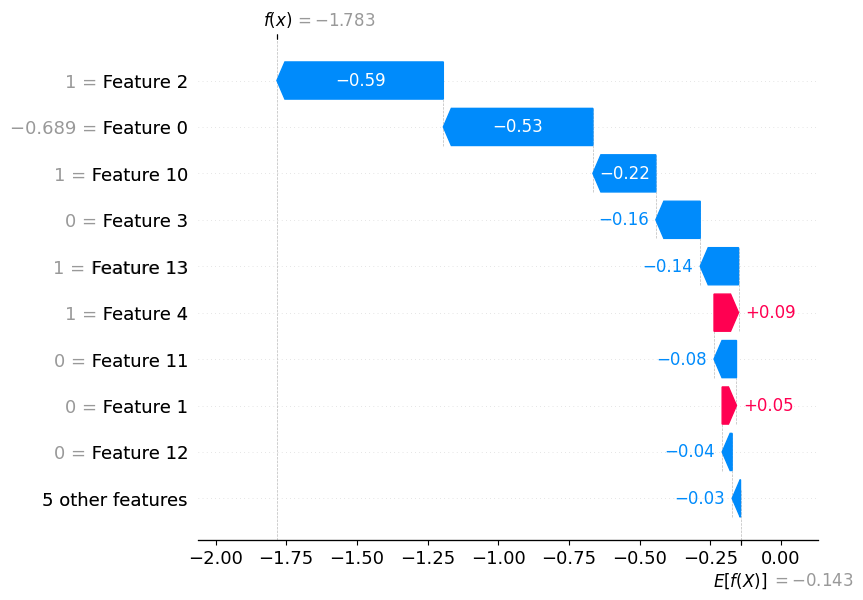

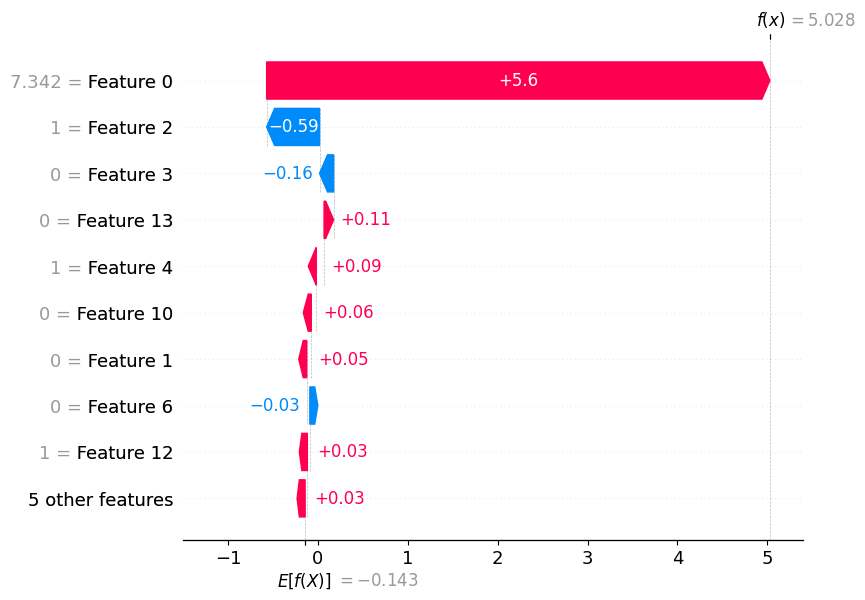

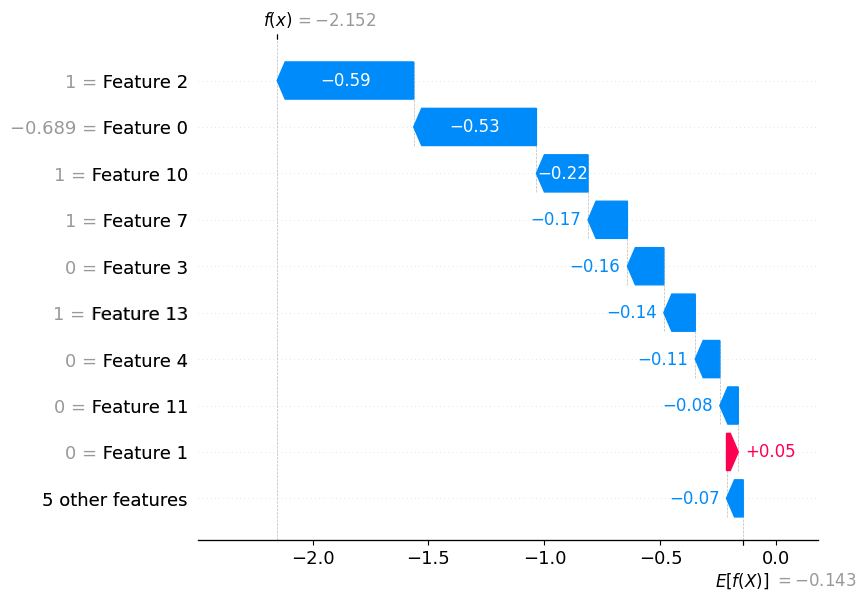

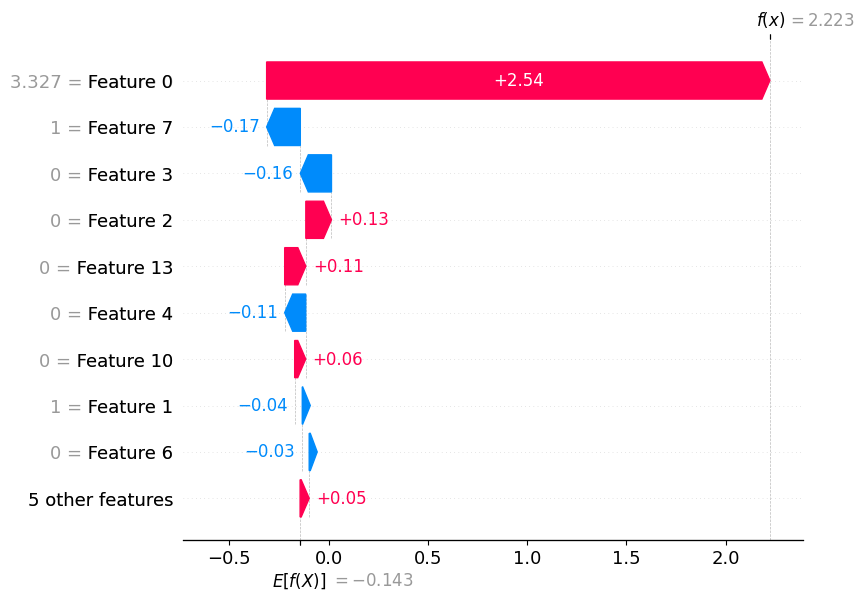

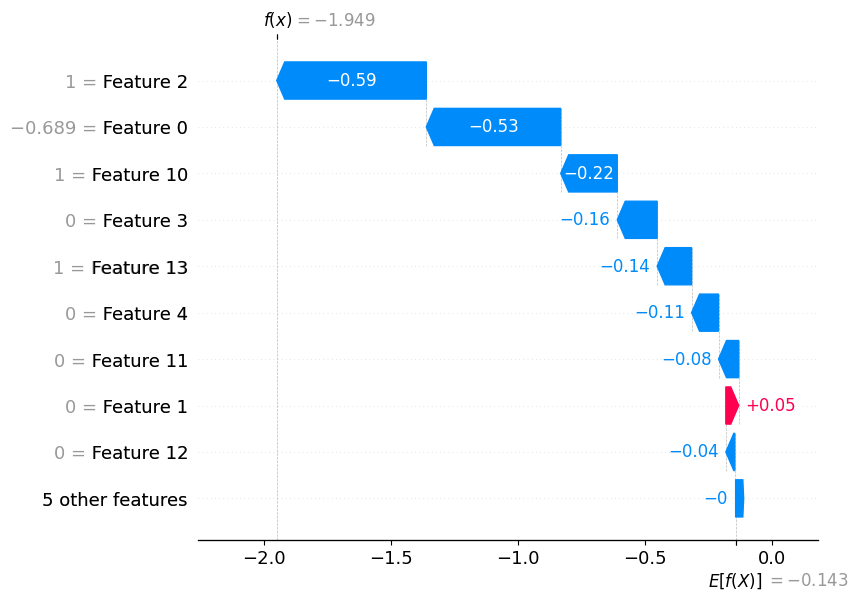

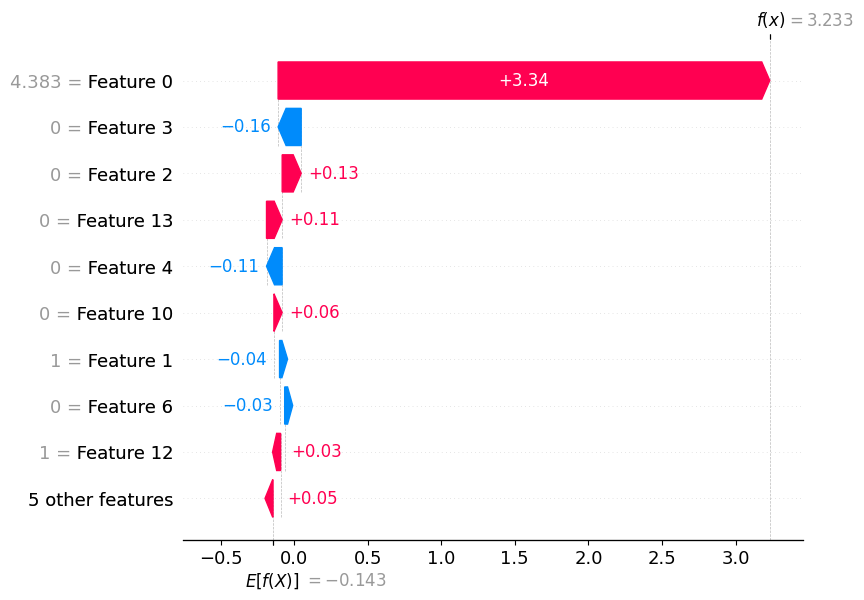

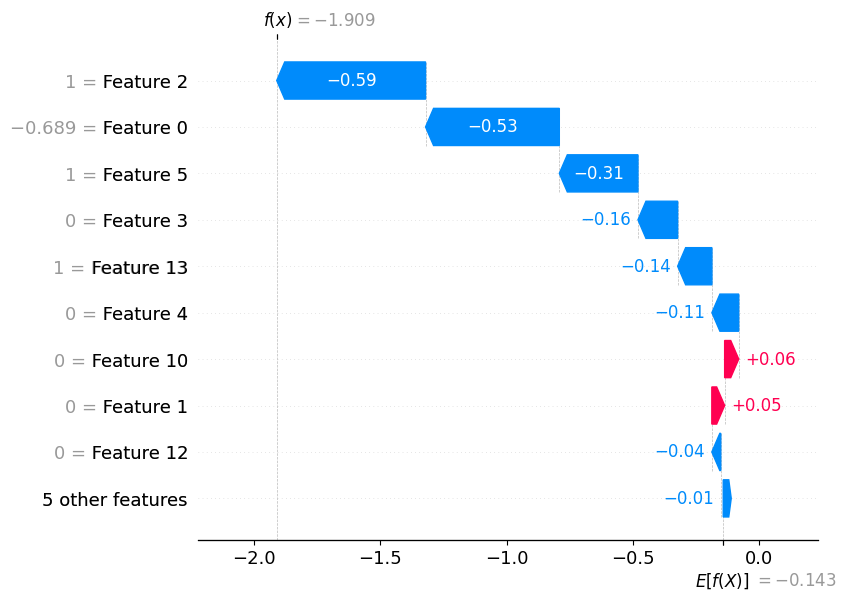

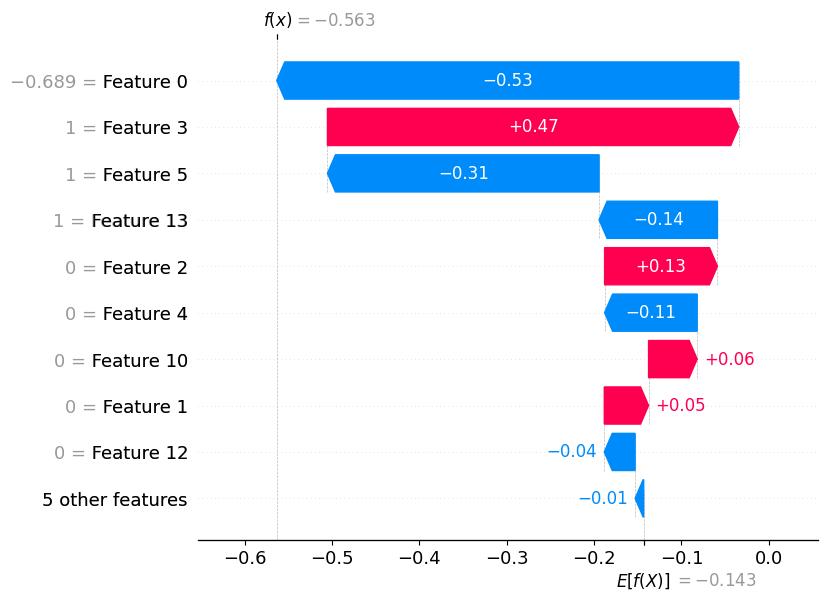

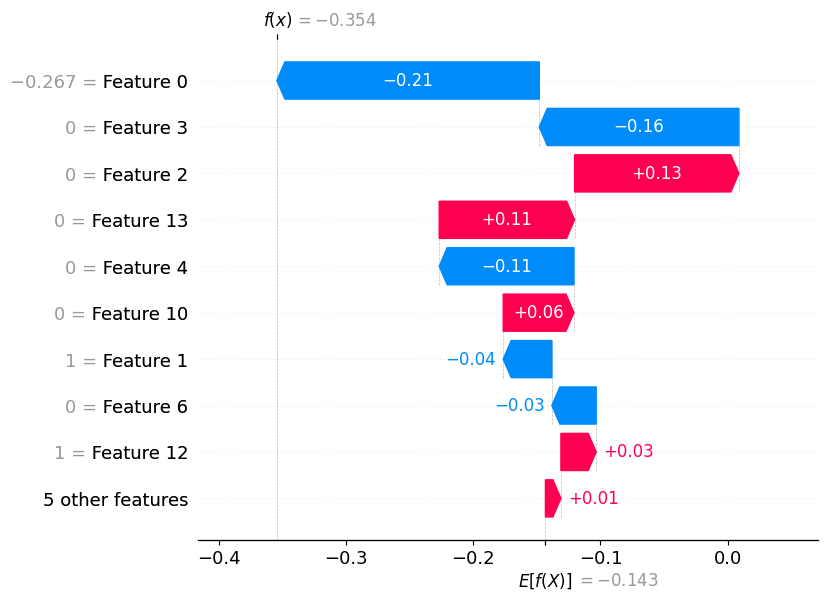

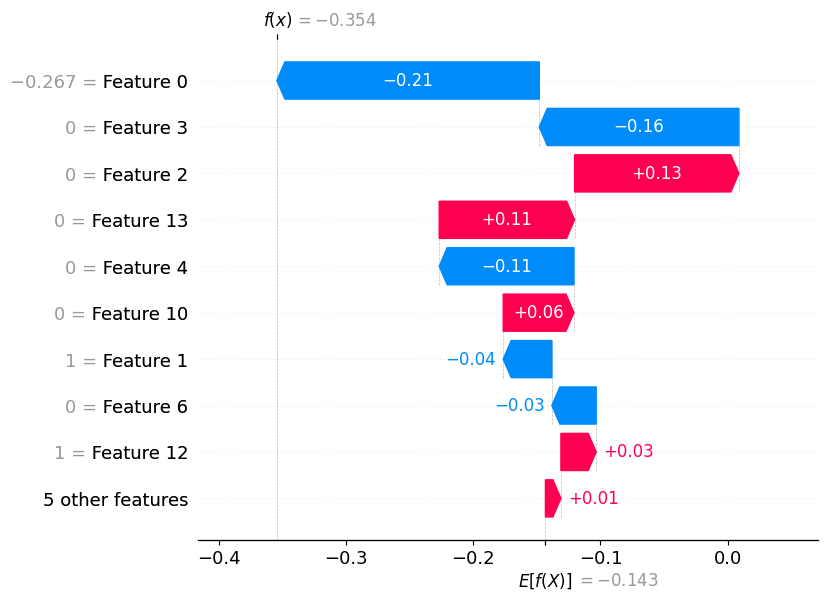

In [53]:
#Waterfall (Individual)
for idx in selected_indices:
    shap.plots.waterfall(shap_values[X_test.index.get_loc(idx)])


Lowest-risk African-American | index=3073 | predicted probability=0.144


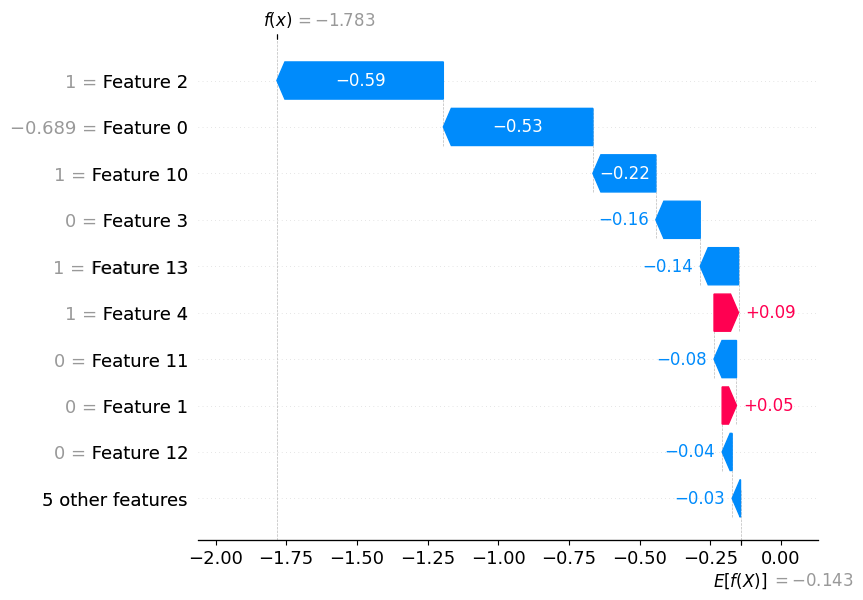


Highest-risk African-American | index=6825 | predicted probability=0.993


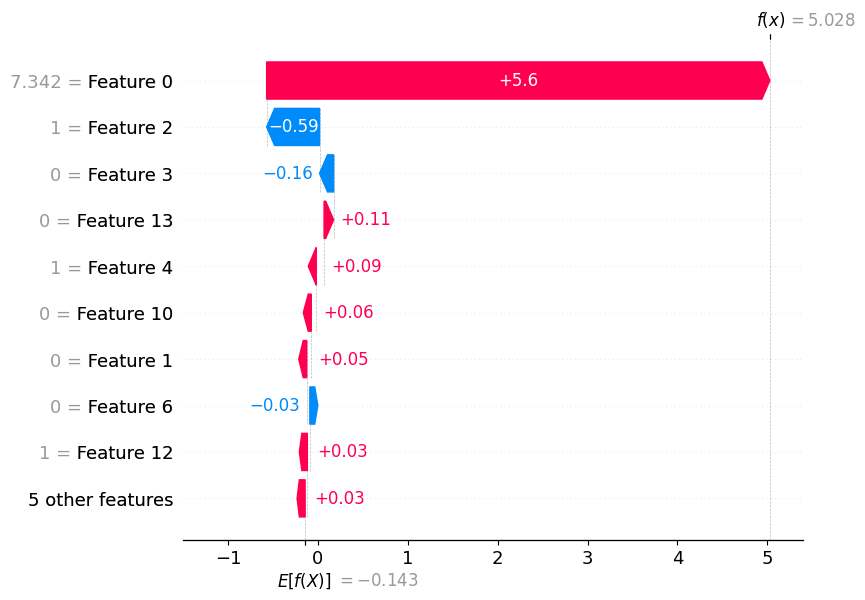


Lowest-risk Caucasian | index=638 | predicted probability=0.133


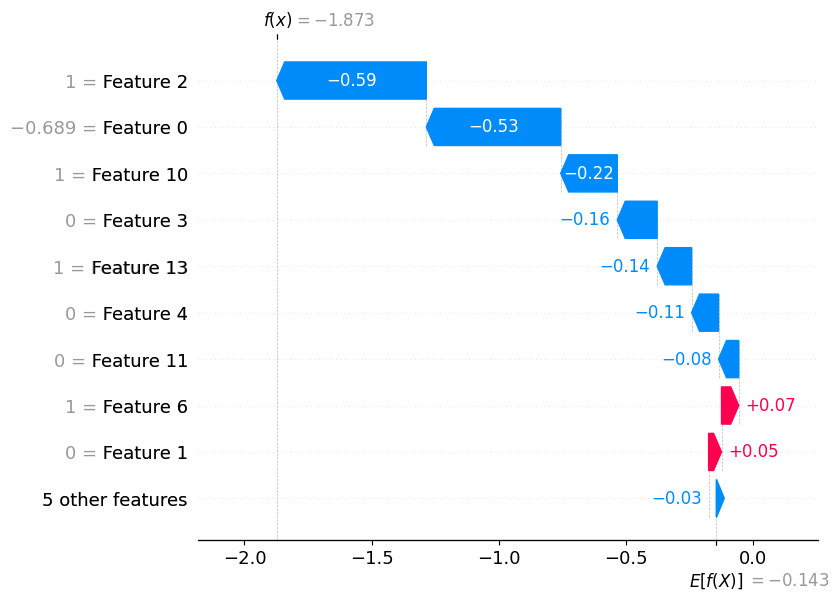


Highest-risk Caucasian | index=6417 | predicted probability=0.946


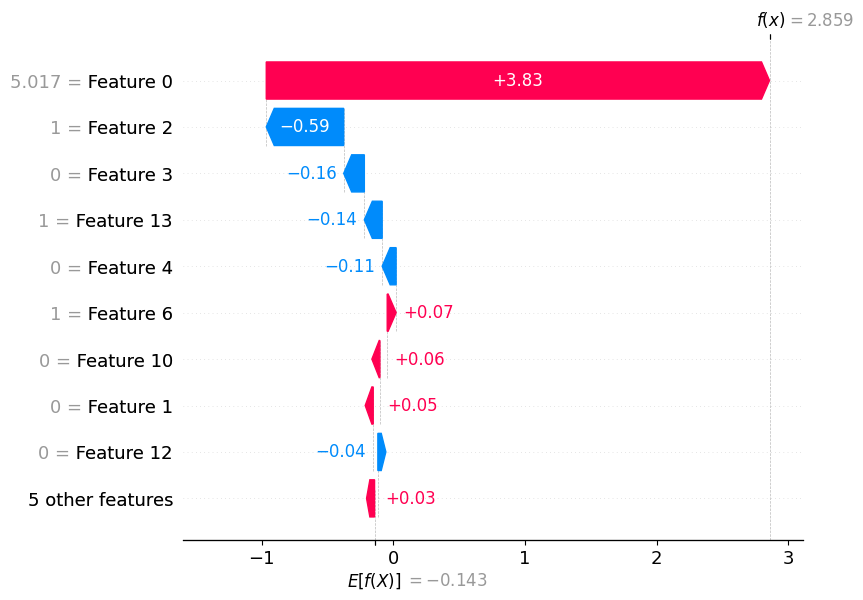

In [54]:
for label, idx in selected_cases.items():
    loc = X_test.index.get_loc(idx)
    print(f"\n{label} | index={idx} | predicted probability={model.predict_proba(X_test.loc[[idx]])[0,1]:.3f}")
    shap.plots.waterfall(shap_values[loc], max_display=10)
    plt.show()

### Note on SHAP Waterfall Labels

The waterfall plots show encoded feature names (e.g., “Feature 2”) instead of original variables because the model uses one-hot encoded inputs. Even though the labels are not fully readable, the plots still show how features affect each prediction.

### SHAP Waterfall Interpretation

The waterfall plots explain how each prediction is built from the baseline. Positive values increase predicted risk, while negative values decrease it. Higher-risk individuals are pushed up by stronger positive contributions, while lower-risk individuals are pushed down more by negative contributions.

In [55]:
# LIME ANALYSIS
!pip install lime

In [56]:
print(df[["priors_count", "age_factor", "race_factor", "gender_factor", "crime_factor"]].head())

   priors_count       age_factor       race_factor gender_factor crime_factor
0             0  Greater than 45             Other          Male            F
1             0          25 - 45  African-American          Male            F
2             4     Less than 25  African-American          Male            F
5             0          25 - 45             Other          Male            M
6            14          25 - 45         Caucasian          Male            F


In [57]:
from lime.lime_tabular import LimeTabularExplainer

# Transform training data
X_train_enc = preprocessor.fit_transform(X_train)

# Feature names after encoding
feature_names = numeric_features + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)

# LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Explain selected individuals
for idx in selected_indices:
    row_enc = preprocessor.transform(X_test.loc[[idx]])

    exp = explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=model["classifier"].predict_proba,
        num_features=5
    )

    print(f"\nLIME explanation for index {idx}")
    print(exp.as_list())


LIME explanation for index 638
[('age_factor_Greater than 45 > 0.00', -0.15601100235671725), ('age_factor_Less than 25 <= 0.00', -0.1469459974924173), ('priors_count <= -0.69', -0.06670102676789537), ('gender_factor_Female > 0.00', -0.05824980916477652), ('0.00 < crime_factor_M <= 1.00', -0.05467143735985125)]

LIME explanation for index 6417
[('priors_count > 0.16', 0.29000022650410445), ('age_factor_Greater than 45 > 0.00', -0.15363514425050262), ('age_factor_Less than 25 <= 0.00', -0.14004987073088343), ('gender_factor_Female <= 0.00', 0.05822358057612975), ('0.00 < crime_factor_M <= 1.00', -0.05261830844183103)]

LIME explanation for index 3073
[('age_factor_Greater than 45 > 0.00', -0.15172009584234028), ('age_factor_Less than 25 <= 0.00', -0.13149299486653163), ('priors_count <= -0.69', -0.06996173498257761), ('gender_factor_Female > 0.00', -0.06672296282395554), ('0.00 < crime_factor_M <= 1.00', -0.0490904496771385)]

LIME explanation for index 6825
[('priors_count > 0.16', 0.2

### Comparing LIME and SHAP

LIME and SHAP generally agree on the main features driving predictions, such as prior arrests and age. However, they do not always rank or weight features the same way. This is because LIME focuses on local approximations, while SHAP distributes contributions across features more systematically.

This difference matters for governance. If explanations vary across methods, they should be treated as helpful tools rather than definitive proof of how the model works. In high-stakes settings, this suggests the need for additional auditing and caution.

In [58]:
#COUNTERFACTUALS (DiCE)
!pip install dice-ml

In [59]:
import dice_ml
from dice_ml import Dice

data_dice = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=numeric_features,
    outcome_name="two_year_recid"
)

model_dice = dice_ml.Model(
    model=model,
    backend="sklearn",
    model_type="classifier"
)

exp = Dice(data_dice, model_dice)

for idx in selected_indices:
    query = X_test.loc[[idx]]
    cf = exp.generate_counterfactuals(
        query,
        total_CFs=2,
        desired_class="opposite"
    )
    cf.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  6.12it/s]

Query instance (original outcome : 0)


,priors_count,age_factor,race_factor,gender_factor,crime_factor,two_year_recid
0,0,Greater than 45,Caucasian,Female,M,0



Diverse Counterfactual set (new outcome: 1)


,priors_count,age_factor,race_factor,gender_factor,crime_factor,two_year_recid
0,17,Greater than 45,Caucasian,Female,F,1
1,37,Greater than 45,Hispanic,Female,M,1


...

100%|██████████| 1/1 [00:00<00:00,  1.56it/s]

Query instance (original outcome : 0)


,priors_count,age_factor,race_factor,gender_factor,crime_factor,two_year_recid
0,2,25 - 45,Native American,Male,F,0



Diverse Counterfactual set (new outcome: 1)


,priors_count,age_factor,race_factor,gender_factor,crime_factor,two_year_recid
0,4,Less than 25,Native American,Male,F,1
1,32,25 - 45,Native American,Male,F,1


## Conclusion

This assignment used SHAP, LIME, and counterfactuals to explain the COMPAS replacement model. SHAP provided global and individual explanations, LIME offered local insights, and DiCE showed how predictions could be changed.

Together, these methods give a more complete view of model behavior. However, they also show that explanations are not perfect and should be used alongside fairness checks and human oversight.

### Governance Memo

This analysis uses SHAP, LIME, and counterfactual explanations to better understand the behavior of the COMPAS replacement model. Together, these methods provide insight into how the model makes predictions, both at a global level and for individual defendants.

The results show that the model is largely driven by features such as prior arrests and age, which aligns with expectations from the data. SHAP provides a consistent decomposition of predictions relative to the average prediction, while LIME offers local approximations for individual cases. In many instances, these methods agree on the key drivers of risk, but there are also cases where they diverge. This highlights the alignment gap between the model’s internal logic and how we interpret its decisions.

Counterfactual explanations further show the minimal changes needed to flip predictions. While these are useful for understanding recourse, some counterfactuals may require changes to immutable features such as race or sex. These cases should be flagged, as they do not represent meaningful or valid interventions.

From a governance perspective, these findings suggest that explanation methods should be treated as diagnostic tools rather than proof of fairness. Agreement between methods increases confidence, but disagreement signals the need for further auditing. In particular, fairness metrics such as error rate parity should be monitored alongside explanations to detect potential harms.

Overall, while the model is interpretable by design, it still requires careful monitoring under distribution shift and ongoing evaluation to ensure that its predictions remain aligned with the intended human objectives.
